In [2]:
DATA_DIR_BULK = '/net/shendure/vol1/home/hdkim615/data/genome_editing_dna_tape_single_unit/6m_circular_dna_tape_mouse_embryo/e13.5_embryo3_tape_bulk_gdna_260824'
DATA_DIR_SCI = '/net/shendure/vol1/home/hdkim615/data/genome_editing_dna_tape_single_unit/6m_circular_dna_tape_mouse_embryo/e13.5_embryo3_sci_260824'
FIG_DIR = '/net/shendure/vol1/home/hdkim615/project/mouse_embryo_lineage_tracing/figure_files/260824_e13.5_embryo3_tape'

In [3]:
sci = pd.read_table('/net/shendure/vol10/www/content/members/cxqiu/private/nobackup/tapemouse/cell_metadata.v8.txt')
sci

,cell_id,major_trajectory,celltype,UMAP_1,UMAP_2,UMAP_3,UMAP_2d_1,UMAP_2d_2
0,exp1_PA-02A.LIG-P8-F09_RT-P8-H07,Mesoderm,Sclerotome,-1.331467,1.556831,7.705772,6.661294,0.532222
1,exp1_PA-02A.LIG-P8-D11_RT-P7-C07,Neuroectoderm_and_glia,Telencephalon,-2.735936,1.135427,-2.464329,15.325320,11.538393
2,exp1_PA-02A.LIG-P6-D07_RT-P7-D12,Mesoderm,Facial mesenchyme,-0.770794,1.963467,8.995356,8.153284,1.527275
3,exp1_PA-02A.LIG-P8-A09_RT-P8-C12,Intermediate_neuronal_progenitors,Deep-layer neurons,-0.594400,-2.471391,-5.293236,8.509349,15.451838
4,exp1_PA-02A.LIG-P7-H07_RT-P8-A07,Neuroectoderm_and_glia,Hindbrain,-3.119302,2.916849,-1.186362,15.371769,9.606669
...,...,...,...,...,...,...,...,...
1584843,exp2_PY-12H.LIG-P5-A08_RT-P7-F07,Epithelium,Pre-epidermal keratinocytes,-7.357510,-0.345629,5.989002,6.942175,-5.397329
1584844,exp2_PY-12H.LIG-P5-B07_RT-P3-A02,CNS_neurons,Glutamatergic neurons,-1.327957,0.792825,-6.874168,17.258156,15.671699
1584845,exp2_PY-12H.LIG-P5-B07_RT-P3-A06,Neuroectoderm_and_glia,Midbrain,-2.863674,1.843398,-2.183982,15.626707,11.047598
1584846,exp2_PY-12H.LIG-P6-G07_RT-P7-D02,Definitive_erythroid,Definitive early erythroblasts (CD36-),11.492424,-1.709149,3.299949,0.344228,14.956079


In [4]:
b1 = pd.read_table(f'{DATA_DIR_SCI}/e3v8.B1_tape_consensus.tsv.gz')
b1

,cell_id,CGGGGAATTGTA,TCCGGAAGACCC,GTGTAAATCGGC,TGACTAAAGCGG,TAACGAATGCCG,TGGGGAACATAT,ATATCAAATTGA,CATATAATCGCA,AATAGAAAACGA,CGGCGAAAAGGT,CAGCTAACGCCT,n_loci,n_doublet_loci,mean_dominance,pass_qc
0,exp1_PA-02A.LIG-P3-A01_RT-P3-B07,NaN,NaN,NaN,NaN,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,NaN,NaN,CCG|CAC|AAG|AAG|CAC|CAC,2,0,1.0,0
1,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,NaN,AAG|GCC|U|U|U|U,GCC|CCC|GATG|AAG|CAC|CAC,GCC|AAG|GCC|U|U|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|U|U|U|U,ACG|GCC|CCC|CAC|U|U,CAC|AAG|GATG|CAC|AAG|AAG,NaN,7,0,1.0,1
2,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,NaN,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CTG|AAG|AAG,GGC|CCC|CCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|CCC|CCC|AAG|U,CAC|AAG|GCC|CAC|GCC|GCC,NaN,7,0,1.0,1
3,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,AAG|AAG|CAC|GCC|ACT|CAC,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CAC|CTG|CCC,GGC|CCC|GCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|GCC|CTG|U|U,CAC|AAG|CTG|ACA|GATG|AAG,CCG|CAC|GATG|ACA|AAG|U,9,0,1.0,1
4,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,NaN,AAG|CAC|AAG|GCC|AAG|GCC,NaN,GCC|AAG|GCC|AAG|AAG|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,ACG|GCC|GCC|AAG|U|U,CAC|AAG|CAC|AAG|CAC|AAG,CCG|CAC|ACA|CCC|GATG|U,6,0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889844,exp2_PY-12H.LIG-P6-H11_RT-P3-B09,NaN,AAG|CCC|AAG|GCC|AAG|GCC,GCC|AAG|CCC|GCC|CAC|CAC,GCC|AAG|GCC|CCC|U|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,ACG|GCC|GCC|CAC|U|U,CAC|AAG|AAG|GCC|AAG|AAG,NaN,6,0,1.0,1
889845,exp2_PY-12H.LIG-P6-H11_RT-P5-G06,AAG|AAG|CAC|GCC|CAC|CTG,NaN,NaN,NaN,GGC|CCC|GCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|CTG|GCC|CTG,NaN,NaN,NaN,4,0,1.0,1
889846,exp2_PY-12H.LIG-P6-H11_RT-P6-H04,AAG|AAG|CAC|U|U|U,NaN,NaN,NaN,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|CCC|GCC|CCC,NaN,CAC|AAG|GATG|CCC|AAG|AAG,CCG|CAC|GATG|CCC|U|U,5,0,1.0,1
889847,exp2_PY-12H.LIG-P6-H12_RT-P7-C03,AAG|AAG|CAC|ACA|CCC|GCC,NaN,GCC|ACT|CCC|U|U|U,GCC|AAG|GCC|CCC|AAG|AAG,NaN,NaN,NaN,AAG|AAG|CAC|AAG|CAC|AAG,ACG|GCC|ACT|GCC|CAC|GATG,CAC|AAG|ACT|ACT|CAC|CAC,CCG|CAC|GCC|CCC|ACA|GCC,7,0,1.0,1


In [5]:
b2 = pd.read_table(f'{DATA_DIR_SCI}/e3v8.B2_tape_consensus.tsv.gz')
b2

,cell_id,CGGGGAATTGTA,TCCGGAAGACCC,GTGTAAATCGGC,TGACTAAAGCGG,TAACGAATGCCG,TGGGGAACATAT,ATATCAAATTGA,CATATAATCGCA,AATAGAAAACGA,CGGCGAAAAGGT,CAGCTAACGCCT,n_loci,n_doublet_loci,mean_dominance,pass_qc
0,exp1_PA-02A.LIG-P3-A07_RT-P7-D09,GCC|GCC|CTG|GCC|GATG|GATG,CAC|GCC|CCC|AAG|AAG|U,NaN,CCC|U|U|U|U|U,CAC|ACT|GCC|CAC|CCC|CCC,NaN,NaN,NaN,GATG|AAG|CTG|U|U|U,CCC|ACT|ACT|AAG|ACT|AAG,ACT|AAG|CCC|GATG|CAC|AAG,7,0,1.000,1
1,exp1_PA-02A.LIG-P3-A10_RT-P5-D07,GCC|GCC|CTG|ACA|CTG|U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1.000,0
2,exp1_PA-02A.LIG-P3-B01_RT-P7-A11,NaN,CAC|GCC|GCC|CCC|AAG|AAG,ACC|ACC|CCC|GCC|GCC|CCC,CCC|U|U|U|U|U,CAC|ACT|GCC|CCC|CCC|CCC,NaN,NaN,ACA|CAC|U|U|U|U,NaN,CCC|AAG|CCC|CCC|AAG|CCC,NaN,6,0,1.000,1
3,exp1_PA-02A.LIG-P3-B03_RT-P6-C12,NaN,CAC|CAC|AAG|CTG|AAG|CTG,ACC|ACC|CCC|GCC|GATG|CCC,CCC|U|U|U|U|U,CAC|ACT|GCC|GCC|CCC|CCC,NaN,NaN,NaN,NaN,CCC|CCC|CTG|CCC|CCC|CTG,CAC|AAG|CCC|U|U|U,6,0,1.000,1
4,exp1_PA-02A.LIG-P3-B03_RT-P8-H11,GCC|GCC|AAG|CCC|CCC|GCC,CAC|CCC|GCC|AAG|CTG|CTG,NaN,ACT|AAG|U|U|U|U,CAC|ACT|GCC|CAC|CCC|AAG,NaN,AAG|ACT|CCC|CCC|U|U,ACA|GCC|GCC|GCC|GCC|GCC,GATG|CCC|CAC|CAC|U|U,CCC|CCC|GCC|CCC|CCC|GCC,CAC|AAG|GCC|GCC|AAG|AAG,9,1,0.996,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653330,exp2_PY-12H.LIG-P6-H10_RT-P7-G12,GCC|GCC|AAG|CCC|AAG|AAG,CAC|AAG|CTG|CAC|U|U,ACC|ACC|CCC|GCC|CCC|AAG,NaN,CAC|ACT|GCC|GCC|U|U,NaN,AAG|ACT|CTG|CAC|AAG|AAG,ACA|CCC|CCC|U|U|U,NaN,CCC|GCC|CAC|GATG|CAC|GATG,GCC|GCC|CAC|CAC|AAG|AAG,8,0,1.000,1
653331,exp2_PY-12H.LIG-P6-H11_RT-P3-B06,GCC|GCC|CCC|AAG|CAC|U,CAC|GCC|CCC|AAG|CCC|AAG,NaN,NaN,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|GCC|ACA|CCC,ACA|GCC|ACA|CTG|GATG|ACT,GATG|GCC|ACT|AAG|GCC|GCC,NaN,GCC|CCC|CCC|U|U|U,7,0,1.000,1
653332,exp2_PY-12H.LIG-P6-H11_RT-P6-H12,NaN,NaN,NaN,NaN,NaN,NaN,AAG|ACT|U|U|U|U,NaN,GATG|CTG|AAG|U|U|U,CCC|U|U|U|U|U,NaN,3,0,1.000,0
653333,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,GCC|GCC|GCC|CCC|AAG|U,CAC|CCC|GCC|CTG|GATG|GATG,NaN,CCC|U|U|U|U|U,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|ACT|CCC|GCC,NaN,GATG|CCC|GCC|U|U|U,CCC|ACA|CCC|CCC|ACA|CCC,CCC|GCC|CTG|CAC|CCC|CCC,8,0,1.000,1


In [6]:
b1['batch'] = 'B1'
b2['batch'] = 'B2'

consensus = pd.concat([b1, b2], ignore_index=True)
consensus

,cell_id,CGGGGAATTGTA,TCCGGAAGACCC,GTGTAAATCGGC,TGACTAAAGCGG,TAACGAATGCCG,TGGGGAACATAT,ATATCAAATTGA,CATATAATCGCA,AATAGAAAACGA,CGGCGAAAAGGT,CAGCTAACGCCT,n_loci,n_doublet_loci,mean_dominance,pass_qc,batch
0,exp1_PA-02A.LIG-P3-A01_RT-P3-B07,NaN,NaN,NaN,NaN,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,NaN,NaN,CCG|CAC|AAG|AAG|CAC|CAC,2,0,1.0,0,B1
1,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,NaN,AAG|GCC|U|U|U|U,GCC|CCC|GATG|AAG|CAC|CAC,GCC|AAG|GCC|U|U|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|U|U|U|U,ACG|GCC|CCC|CAC|U|U,CAC|AAG|GATG|CAC|AAG|AAG,NaN,7,0,1.0,1,B1
2,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,NaN,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CTG|AAG|AAG,GGC|CCC|CCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|CCC|CCC|AAG|U,CAC|AAG|GCC|CAC|GCC|GCC,NaN,7,0,1.0,1,B1
3,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,AAG|AAG|CAC|GCC|ACT|CAC,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CAC|CTG|CCC,GGC|CCC|GCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|GCC|CTG|U|U,CAC|AAG|CTG|ACA|GATG|AAG,CCG|CAC|GATG|ACA|AAG|U,9,0,1.0,1,B1
4,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,NaN,AAG|CAC|AAG|GCC|AAG|GCC,NaN,GCC|AAG|GCC|AAG|AAG|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,ACG|GCC|GCC|AAG|U|U,CAC|AAG|CAC|AAG|CAC|AAG,CCG|CAC|ACA|CCC|GATG|U,6,0,1.0,1,B1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543179,exp2_PY-12H.LIG-P6-H10_RT-P7-G12,GCC|GCC|AAG|CCC|AAG|AAG,CAC|AAG|CTG|CAC|U|U,ACC|ACC|CCC|GCC|CCC|AAG,NaN,CAC|ACT|GCC|GCC|U|U,NaN,AAG|ACT|CTG|CAC|AAG|AAG,ACA|CCC|CCC|U|U|U,NaN,CCC|GCC|CAC|GATG|CAC|GATG,GCC|GCC|CAC|CAC|AAG|AAG,8,0,1.0,1,B2
1543180,exp2_PY-12H.LIG-P6-H11_RT-P3-B06,GCC|GCC|CCC|AAG|CAC|U,CAC|GCC|CCC|AAG|CCC|AAG,NaN,NaN,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|GCC|ACA|CCC,ACA|GCC|ACA|CTG|GATG|ACT,GATG|GCC|ACT|AAG|GCC|GCC,NaN,GCC|CCC|CCC|U|U|U,7,0,1.0,1,B2
1543181,exp2_PY-12H.LIG-P6-H11_RT-P6-H12,NaN,NaN,NaN,NaN,NaN,NaN,AAG|ACT|U|U|U|U,NaN,GATG|CTG|AAG|U|U|U,CCC|U|U|U|U|U,NaN,3,0,1.0,0,B2
1543182,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,GCC|GCC|GCC|CCC|AAG|U,CAC|CCC|GCC|CTG|GATG|GATG,NaN,CCC|U|U|U|U|U,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|ACT|CCC|GCC,NaN,GATG|CCC|GCC|U|U|U,CCC|ACA|CCC|CCC|ACA|CCC,CCC|GCC|CTG|CAC|CCC|CCC,8,0,1.0,1,B2


In [7]:
consensus_qc = consensus[consensus['pass_qc'] == 1].copy()
print(f'{len(consensus_qc)} of {len(consensus)} cells pass QC')

1296799 of 1543184 cells pass QC


# Reviewer 2's comment 5

In [8]:
# CGGCGAAAAGGT is missing

tapebc2insertbc = {
    'CGGGGAATTGTA': 'CTGGGA',
    'TGACTAAAGCGG': 'ATTGGA',
    'TCCGGAAGACCC': 'GATGGGA',
    'TGGGGAACATAT': 'ACAGGA',
    'CATATAATCGCA': 'GCCGGA',
    'TAACGAATGCCG': 'AAGGGA',
    'GTGTAAATCGGC': 'CACGGA',
    'CAGCTAACGCCT': 'CCCGGA',
    'ATATCAAATTGA': 'ACTGGA',
    'AATAGAAAACGA': 'CACGGA',
}

In [9]:
def strip_gga_suffix(insertbc):
    return insertbc[:-3] if insertbc.endswith('GGA') else insertbc

tapebc2insert = {tapebc: strip_gga_suffix(insertbc) for tapebc, insertbc in tapebc2insertbc.items()}
tapebc2insert

{'CGGGGAATTGTA': 'CTG',
 'TGACTAAAGCGG': 'ATT',
 'TCCGGAAGACCC': 'GATG',
 'TGGGGAACATAT': 'ACA',
 'CATATAATCGCA': 'GCC',
 'TAACGAATGCCG': 'AAG',
 'GTGTAAATCGGC': 'CAC',
 'CAGCTAACGCCT': 'CCC',
 'ATATCAAATTGA': 'ACT',
 'AATAGAAAACGA': 'CAC'}

In [10]:
tapebcs = list(tapebc2insertbc.keys())
print(f'{len(tapebcs)} tapebc: {tapebcs}')

10 tapebc: ['CGGGGAATTGTA', 'TGACTAAAGCGG', 'TCCGGAAGACCC', 'TGGGGAACATAT', 'CATATAATCGCA', 'TAACGAATGCCG', 'GTGTAAATCGGC', 'CAGCTAACGCCT', 'ATATCAAATTGA', 'AATAGAAAACGA']


In [11]:
all_symbols = ['CTG', 'GCC', 'AAG', 'CAC', 'GATG', 'CCC', 'ACA', 'ACT']
print(f'{len(all_symbols)} symbols: {all_symbols}')

8 symbols: ['CTG', 'GCC', 'AAG', 'CAC', 'GATG', 'CCC', 'ACA', 'ACT']


In [12]:
MONOMER_POSITIONS = [3, 4, 5, 6]  # 1-indexed, pooled

tapebc2total_obs = {tbc: 0 for tbc in tapebcs}
tapebc2symbol_obs = {tbc: {s: 0 for s in all_symbols} for tbc in tapebcs}

for tapebc in tapebcs:
    genotypes = consensus_qc[tapebc].dropna()
    for genotype_str in genotypes:
        monomers = genotype_str.split('|')
        if len(monomers) != 6: continue
        for pos in MONOMER_POSITIONS:
            monomer = monomers[pos - 1]
            if monomer in all_symbols:
                tapebc2total_obs[tapebc] += 1
                tapebc2symbol_obs[tapebc][monomer] += 1

In [13]:
total_obs_overall = sum(tapebc2total_obs.values())
symbol_obs_overall = {s: sum(tapebc2symbol_obs[tbc][s] for tbc in tapebcs) for s in all_symbols}
rate_overall = {s: symbol_obs_overall[s] / total_obs_overall for s in all_symbols}

print('\noverall rate per symbol (across all 10 tapes):')
for s in all_symbols:
    print(f'  {s}: {rate_overall[s]:.4f}')


overall rate per symbol (across all 10 tapes):
  CTG: 0.0539
  GCC: 0.2100
  AAG: 0.2384
  CAC: 0.1191
  GATG: 0.0597
  CCC: 0.1837
  ACA: 0.0304
  ACT: 0.1048


In [14]:
relative_rate = {}
for tapebc in tapebcs:
    total = tapebc2total_obs[tapebc]
    relative_rate[tapebc] = {}
    for s in all_symbols:
        rate_at_tape = tapebc2symbol_obs[tapebc][s] / total if total > 0 else 0
        relative_rate[tapebc][s] = rate_at_tape / rate_overall[s] if rate_overall[s] > 0 else np.nan

log2_relative_rate = {
    tbc: {s: np.log2(relative_rate[tbc][s]) if relative_rate[tbc][s] > 0 else np.nan for s in all_symbols}
    for tbc in tapebcs
}

In [15]:
from matplotlib.patches import Patch

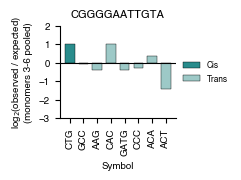

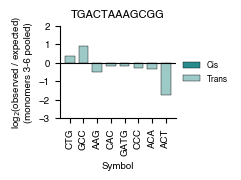

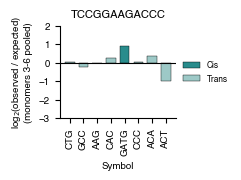

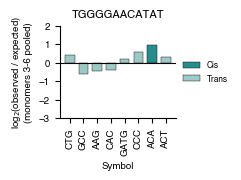

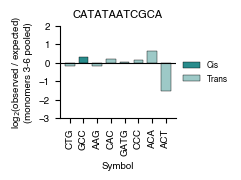

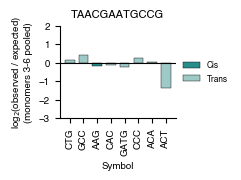

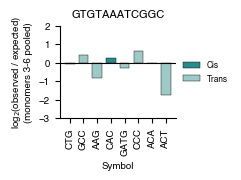

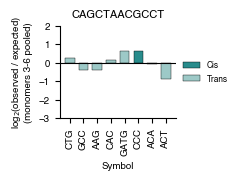

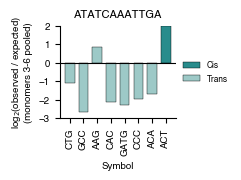

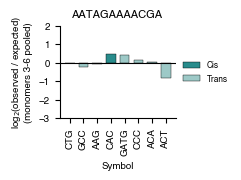

In [16]:
all_values = [log2_relative_rate[tbc][s] for tbc in tapebcs for s in all_symbols
              if not np.isnan(log2_relative_rate[tbc][s])]

positive_values = [v for v in all_values if v > 0]
negative_values = [v for v in all_values if v < 0]

y_max_pos = 0
while y_max_pos < np.max(positive_values): y_max_pos += 1

y_max_neg = 0
while y_max_neg < np.max(np.abs(negative_values)): y_max_neg += 1

for tapebc in tapebcs:
    own_symbol = tapebc2insert[tapebc]
    values = [log2_relative_rate[tapebc][s] for s in all_symbols]
    colors = ['#298C8C' if s == own_symbol else '#9DC9C7' for s in all_symbols]

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.2))
    xloc = np.arange(len(all_symbols))
    ax.bar(xloc, values, width=0.7, color=colors, edgecolor='black', linewidth=0.3, zorder=100)

    axis_linewidth = ax.spines['bottom'].get_linewidth()
    ax.axhline(y=0, color='black', linestyle='-', linewidth=axis_linewidth, zorder=101)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(xloc)
    ax.set_xticklabels(all_symbols, rotation=90, ha='center', fontsize=7)
    
    ax.set_xlabel('Symbol')
    ax.set_ylabel('log$_2$(observed / expected)\n(monomers 3-6 pooled)')
    ax.set_ylim(-y_max_neg, y_max_pos)
    ax.set_yticks(np.arange(-y_max_neg, y_max_pos + 0.5, 1))
    ax.set_title(tapebc, fontsize=8)

    legend_handles = [
        Patch(facecolor='#298C8C', edgecolor='black', linewidth=0.3, label='Cis'),
        Patch(facecolor='#9DC9C7', edgecolor='black', linewidth=0.3, label='Trans'),
    ]
    ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=6)
    
    #plt.savefig(f'{FIG_DIR}/cis_trans_relative_proportion_by_edit.{tapebc}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Reviewer 2's comment 6

In [17]:
tape = pd.read_table(f'{DATA_DIR_BULK}/DTTz_3_S3.bulk_lineage_genotypes.csv', sep=',')
tape

,tapebc,genotype_id,genotype,edit_depth,n_cells,n_reads
0,ATATCAAATTGA,ATATCAAATTGA_g001,GATG|ACT|ACT|AAG|ACT|AAG,6,211,296284
1,ATATCAAATTGA,ATATCAAATTGA_g002,AAG|ACT|U|U|U|U,2,11,16023
2,ATATCAAATTGA,ATATCAAATTGA_g003,AAG|ACT|GCC|U|U|U,3,10,13546
3,ATATCAAATTGA,ATATCAAATTGA_g004,AAG|ACT|CCC|U|U|U,3,8,10661
4,ATATCAAATTGA,ATATCAAATTGA_g005,ACT|ACT|AAG|ACT|ACT|AAG,6,6,9017
...,...,...,...,...,...,...
1267,TAACGAATGCCG,TAACGAATGCCG_g087,GGC|CCC|GCC|GCC|AAG|AAG,6,1,2169
1268,TAACGAATGCCG,TAACGAATGCCG_g088,GGC|CTG|AAG|U|U|U,3,1,1007
1269,TAACGAATGCCG,TAACGAATGCCG_g089,GGC|CTG|AAG|AAG|AAG|GCC,6,1,1807
1270,TAACGAATGCCG,TAACGAATGCCG_g090,GGC|CTG|GCC|GCC|U|U,4,1,1721


In [18]:
tape_columns = sorted(tape['tapebc'].unique())
tape_columns

['AATAGAAAACGA',
 'ATATCAAATTGA',
 'CAGCTAACGCCT',
 'CATATAATCGCA',
 'CGGCGAAAAGGT',
 'CGGGGAATTGTA',
 'GTGTAAATCGGC',
 'TAACGAATGCCG',
 'TCCGGAAGACCC',
 'TGACTAAAGCGG',
 'TGGGGAACATAT']

In [19]:
tapebc2color = {'AATAGAAAACGA': '#aec7e8',
 'ATATCAAATTGA': '#1f77b4',
 'CAGCTAACGCCT': '#98df8a',
 'CATATAATCGCA': '#2ca02c',
 'CGGCGAAAAGGT': '#ff9896',
 'CGGGGAATTGTA': '#d62728',
 'GTGTAAATCGGC': '#ffbb78',
 'TAACGAATGCCG': '#ff7f0e',
 'TCCGGAAGACCC': '#c5b0d5',
 'TGACTAAAGCGG': '#9467bd',
 'TGGGGAACATAT': '#8c564b'}

In [20]:
n_positions = 6

In [21]:
tapebc2position_total = {}
tapebc2position_insert_reads = {}

for _, row in tape.iterrows():
    tapebc = row['tapebc']
    n_reads = row['n_reads']
    monomers = row['genotype'].split('|')
    if len(monomers) != n_positions:
        continue

    if tapebc not in tapebc2position_total:
        tapebc2position_total[tapebc] = np.zeros(n_positions)
        tapebc2position_insert_reads[tapebc] = {}

    for i, monomer in enumerate(monomers):
        tapebc2position_total[tapebc][i] += n_reads
        if monomer not in tapebc2position_insert_reads[tapebc]:
            tapebc2position_insert_reads[tapebc][monomer] = np.zeros(n_positions)
        tapebc2position_insert_reads[tapebc][monomer][i] += n_reads

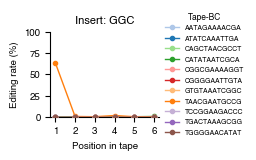

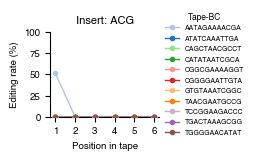

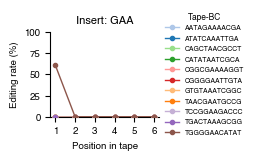

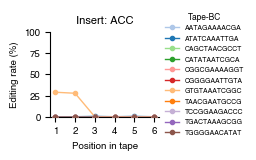

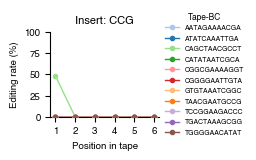

In [22]:
xloc = np.arange(1, n_positions + 1)

for insert in ['GGC', 'ACG', 'GAA', 'ACC', 'CCG']:
    fig, ax = plt.subplots(1, 1, figsize=(1.4, 1.1))

    for tapebc in tape_columns:
        position_total = tapebc2position_total[tapebc]
        insert_reads = tapebc2position_insert_reads[tapebc].get(insert, np.zeros(n_positions))

        with np.errstate(divide='ignore', invalid='ignore'):
            rate = np.where(position_total > 0, insert_reads / position_total * 100, np.nan)

        #if np.nansum(rate) == 0: continue  # skip tapebc with no occurrence of this insert at all

        ax.plot(xloc, rate, marker='o', markersize=3, linewidth=1,
                 color=tapebc2color[tapebc], label=tapebc, zorder=100)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Position in tape')
    ax.set_ylabel('Editing rate (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks(xloc)
    ax.set_title(f'Insert: {insert}', fontsize=8)
    ax.legend(title='Tape-BC', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=5, title_fontsize=6)
    
    #plt.savefig(f'{FIG_DIR}/editing_rate_by_position.insert_{insert}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Reviewer 2's comment 9

In [23]:
merged = consensus_qc.merge(sci[['cell_id', 'major_trajectory', 'celltype']], on='cell_id', how='inner')
merged

,cell_id,CGGGGAATTGTA,TCCGGAAGACCC,GTGTAAATCGGC,TGACTAAAGCGG,TAACGAATGCCG,TGGGGAACATAT,ATATCAAATTGA,CATATAATCGCA,AATAGAAAACGA,CGGCGAAAAGGT,CAGCTAACGCCT,n_loci,n_doublet_loci,mean_dominance,pass_qc,batch,major_trajectory,celltype
0,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,NaN,AAG|GCC|U|U|U|U,GCC|CCC|GATG|AAG|CAC|CAC,GCC|AAG|GCC|U|U|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|U|U|U|U,ACG|GCC|CCC|CAC|U|U,CAC|AAG|GATG|CAC|AAG|AAG,NaN,7,0,1.0,1,B1,Muscle_cells,Myoblasts
1,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,NaN,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CTG|AAG|AAG,GGC|CCC|CCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|CCC|CCC|AAG|U,CAC|AAG|GCC|CAC|GCC|GCC,NaN,7,0,1.0,1,B1,CNS_neurons,GABAergic cortical interneurons
2,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,AAG|AAG|CAC|GCC|ACT|CAC,NaN,GCC|U|U|U|U|U,GCC|AAG|GCC|CAC|CTG|CCC,GGC|CCC|GCC|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,AAG|AAG|GCC|GCC|GCC|GCC,ACG|GCC|GCC|CTG|U|U,CAC|AAG|CTG|ACA|GATG|AAG,CCG|CAC|GATG|ACA|AAG|U,9,0,1.0,1,B1,CNS_neurons,Glutamatergic neurons
3,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,NaN,AAG|CAC|AAG|GCC|AAG|GCC,NaN,GCC|AAG|GCC|AAG|AAG|U,NaN,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,ACG|GCC|GCC|AAG|U|U,CAC|AAG|CAC|AAG|CAC|AAG,CCG|CAC|ACA|CCC|GATG|U,6,0,1.0,1,B1,Neuroectoderm_and_glia,Telencephalon
4,exp1_PA-02A.LIG-P3-A07_RT-P6-H12,NaN,AAG|CAC|GCC|CCC|GCC|CCC,GCC|CAC|U|U|U|U,GCC|AAG|GCC|CCC|CCC|CCC,GGC|GCC|U|U|U|U,NaN,GATG|ACT|ACT|AAG|ACT|AAG,NaN,ACG|GCC|GATG|CAC|U|U,NaN,CCG|CAC|AAG|GCC|AAG|AAG,7,0,1.0,1,B1,CNS_neurons,Glutamatergic neurons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296794,exp2_PY-12H.LIG-P6-H08_RT-P3-C09,NaN,CAC|CAC|GCC|CCC|GATG|AAG,ACC|ACC|CCC|GCC|AAG|CCC,ACT|CAC|ACT|U|U|U,CAC|ACT|GCC|GCC|AAG|AAG,NaN,NaN,NaN,NaN,CCC|AAG|GCC|CCC|GCC|CCC,CAC|GCC|GATG|U|U|U,6,0,1.0,1,B2,Neural_crest_PNS_glia,Myelinating Schwann cells
1296795,exp2_PY-12H.LIG-P6-H10_RT-P7-G12,GCC|GCC|AAG|CCC|AAG|AAG,CAC|AAG|CTG|CAC|U|U,ACC|ACC|CCC|GCC|CCC|AAG,NaN,CAC|ACT|GCC|GCC|U|U,NaN,AAG|ACT|CTG|CAC|AAG|AAG,ACA|CCC|CCC|U|U|U,NaN,CCC|GCC|CAC|GATG|CAC|GATG,GCC|GCC|CAC|CAC|AAG|AAG,8,0,1.0,1,B2,CNS_neurons,GABAergic neurons
1296796,exp2_PY-12H.LIG-P6-H11_RT-P3-B06,GCC|GCC|CCC|AAG|CAC|U,CAC|GCC|CCC|AAG|CCC|AAG,NaN,NaN,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|GCC|ACA|CCC,ACA|GCC|ACA|CTG|GATG|ACT,GATG|GCC|ACT|AAG|GCC|GCC,NaN,GCC|CCC|CCC|U|U|U,7,0,1.0,1,B2,Epithelium,Branchial arch epithelium
1296797,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,GCC|GCC|GCC|CCC|AAG|U,CAC|CCC|GCC|CTG|GATG|GATG,NaN,CCC|U|U|U|U|U,CAC|ACT|GCC|CCC|AAG|AAG,NaN,AAG|ACT|CTG|ACT|CCC|GCC,NaN,GATG|CCC|GCC|U|U|U,CCC|ACA|CCC|CCC|ACA|CCC,CCC|GCC|CTG|CAC|CCC|CCC,8,0,1.0,1,B2,Mesoderm,Lateral plate and intermediate mesoderm


In [24]:
merged['major_trajectory'].value_counts()

major_trajectory
CNS_neurons                          367228
Mesoderm                             349661
Neuroectoderm_and_glia               211683
Definitive_erythroid                 116332
Intermediate_neuronal_progenitors     52569
Muscle_cells                          48654
Epithelium                            44395
White_blood_cells                     26311
Hepatocytes                           18507
Endothelium                           14173
Neural_crest_PNS_glia                 13999
Neural_crest_PNS_neurons              12945
Eye_and_other                          5213
Olfactory_sensory_neurons              4225
Megakaryocytes                         3903
Lung_and_airway                        1964
Intestine                              1498
Ependymal_cells                        1125
Mast_cells                              940
Cardiomyocytes                          409
Primitive_erythroid                     286
T_cells                                 265
Testis_and_adre

In [25]:
with pd.option_context('display.max_rows', None):
    print(merged['celltype'].value_counts())

celltype
Glutamatergic neurons                         139754
Telencephalon                                 126107
Definitive early erythroblasts (CD36-)        116058
Fibroblasts                                   113906
GABAergic cortical interneurons                89083
GABAergic neurons                              70448
Lateral plate and intermediate mesoderm        50268
Sclerotome                                     42737
Myoblasts                                      40515
Deep-layer neurons                             39099
Midbrain                                       36054
Facial mesenchyme                              35164
Limb mesenchyme progenitors                    29992
Early chondrocytes                             28649
Dermatome                                      24854
Cajal-Retzius cells                            22167
Chondrocytes (Atp1a2+)                         21543
Hepatocytes                                    18512
Pre-epidermal keratinocytes          

In [26]:
recovery = merged[tape_columns].notna()
recovery

,AATAGAAAACGA,ATATCAAATTGA,CAGCTAACGCCT,CATATAATCGCA,CGGCGAAAAGGT,CGGGGAATTGTA,GTGTAAATCGGC,TAACGAATGCCG,TCCGGAAGACCC,TGACTAAAGCGG,TGGGGAACATAT
0,True,True,False,True,True,False,True,False,True,True,False
1,True,True,False,True,True,False,True,True,False,True,False
2,True,True,True,True,True,True,True,True,False,True,False
3,True,True,True,False,True,False,False,False,True,True,False
4,True,True,True,False,False,False,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...
1296794,False,False,True,False,True,False,True,True,True,True,False
1296795,False,True,True,True,True,True,True,True,True,False,False
1296796,True,True,True,True,False,True,False,True,True,False,False
1296797,True,True,True,False,True,True,False,True,True,True,False


In [27]:
# --- 1. overall per-TAPE recovery rate (sanity check against reviewer's reported numbers) ---
overall_recovery = recovery.mean().sort_values(ascending=False) * 100
print('\n--- overall recovery rate per TAPE (%) ---')
print(overall_recovery)


--- overall recovery rate per TAPE (%) ---
CGGCGAAAAGGT    77.314449
TAACGAATGCCG    75.027741
ATATCAAATTGA    74.797019
CATATAATCGCA    73.550411
AATAGAAAACGA    72.702863
TGACTAAAGCGG    70.664305
TCCGGAAGACCC    69.275732
CAGCTAACGCCT    55.559420
GTGTAAATCGGC    54.378820
CGGGGAATTGTA    24.408871
TGGGGAACATAT     4.263575
dtype: float64


In [28]:
recovery_by_trajectory = recovery.copy()
recovery_by_trajectory['major_trajectory'] = merged['major_trajectory'].values
trajectory_recovery = recovery_by_trajectory.groupby('major_trajectory')[tape_columns].mean() * 100
trajectory_recovery = trajectory_recovery.round(1)
trajectory_recovery

,AATAGAAAACGA,ATATCAAATTGA,CAGCTAACGCCT,CATATAATCGCA,CGGCGAAAAGGT,CGGGGAATTGTA,GTGTAAATCGGC,TAACGAATGCCG,TCCGGAAGACCC,TGACTAAAGCGG,TGGGGAACATAT
major_trajectory,,,,,,,,,,,
B_cells,88.1,86.7,88.9,85.9,95.6,16.3,78.5,88.1,90.4,84.4,1.5
CNS_neurons,72.2,76.3,45.5,77.7,75.4,33.0,50.6,81.5,63.6,72.0,7.6
Cardiomyocytes,70.2,60.4,62.6,66.5,61.4,30.6,53.8,71.4,71.1,70.7,6.8
Definitive_erythroid,69.9,74.6,56.3,57.5,80.5,18.6,69.1,61.3,58.0,48.9,1.4
Endothelium,72.6,63.9,59.7,57.4,67.7,10.5,53.3,74.1,67.0,67.3,0.4
Ependymal_cells,79.1,78.0,76.5,82.4,81.1,44.4,71.4,85.6,84.5,80.9,18.0
Epithelium,76.5,80.7,60.2,74.2,80.2,23.9,53.2,72.9,72.3,72.1,3.6
Eye_and_other,75.4,75.5,68.3,84.8,79.3,39.4,65.5,81.8,85.2,84.1,11.8
Hepatocytes,79.0,76.5,65.5,85.8,89.6,21.5,58.3,69.1,73.4,69.4,2.0


In [29]:
poor_tapes = ['CGGGGAATTGTA', 'TGGGGAACATAT']
good_tape_columns = [c for c in tape_columns if c not in poor_tapes]
print(f'using {len(good_tape_columns)} tapes (excluded: {poor_tapes})')

using 9 tapes (excluded: ['CGGGGAATTGTA', 'TGGGGAACATAT'])


In [30]:
import numpy as np
from statsmodels.stats.multitest import multipletests

def permutation_test_by_cell_shuffle_single_tape(recovery_vector, group_labels, target_group, n_permutations=100, seed=0):
    rng = np.random.default_rng(seed)
    n_cells_total = len(recovery_vector)

    target_mask = (group_labels == target_group)
    n_target = target_mask.sum()

    observed_rate = recovery_vector[target_mask].mean() * 100

    null_rates = np.zeros(n_permutations)
    for i in range(n_permutations):
        random_idx = rng.choice(n_cells_total, size=n_target, replace=False)
        null_rates[i] = recovery_vector[random_idx].mean() * 100

    null_mean = null_rates.mean()
    null_sd = null_rates.std(ddof=1)
    p_value = np.mean(np.abs(null_rates - null_mean) >= np.abs(observed_rate - null_mean))

    return observed_rate, null_mean, null_sd, p_value

In [31]:
trajectory_labels = merged['major_trajectory'].values
valid_trajectories = trajectory_recovery.index.tolist()

all_trajectory_results = []
for tape_bc in good_tape_columns:
    recovery_vector = recovery[tape_bc].values

    for trajectory in valid_trajectories:
        observed_rate, null_mean, null_sd, p_value = permutation_test_by_cell_shuffle_single_tape(
            recovery_vector, trajectory_labels, trajectory, n_permutations=100, seed=0
        )
        all_trajectory_results.append({
            'tapebc': tape_bc,
            'major_trajectory': trajectory,
            'observed_rate': observed_rate,
            'null_mean_rate': null_mean,
            'null_sd': null_sd,
            'diff_from_null': observed_rate - null_mean,
            'perm_p_value': p_value,
        })

all_trajectory_results_df = pd.DataFrame(all_trajectory_results)
all_trajectory_results_df['perm_p_adjusted'] = multipletests(all_trajectory_results_df['perm_p_value'], method='fdr_bh')[1]

FOLD_CHANGE_THRESHOLD = 1.5
all_trajectory_results_df['fold_change'] = all_trajectory_results_df['observed_rate'] / all_trajectory_results_df['null_mean_rate']

all_trajectory_results_df['sig_low'] = (all_trajectory_results_df['perm_p_adjusted'] < 0.05) & (all_trajectory_results_df['fold_change'] <= 1 / FOLD_CHANGE_THRESHOLD)
all_trajectory_results_df['sig_high'] = (all_trajectory_results_df['perm_p_adjusted'] < 0.05) & (all_trajectory_results_df['fold_change'] >= FOLD_CHANGE_THRESHOLD)
all_trajectory_results_df

,tapebc,major_trajectory,observed_rate,null_mean_rate,null_sd,diff_from_null,perm_p_value,perm_p_adjusted,fold_change,sig_low,sig_high
0,AATAGAAAACGA,B_cells,88.148148,72.259259,3.626391,15.888889,0.00,0.000000,1.219887,False,False
1,AATAGAAAACGA,CNS_neurons,72.174780,72.702030,0.052507,-0.527250,0.00,0.000000,0.992748,False,False
2,AATAGAAAACGA,Cardiomyocytes,70.171149,72.696822,2.278826,-2.525672,0.31,0.340244,0.965257,False,False
3,AATAGAAAACGA,Definitive_erythroid,69.900801,72.692681,0.139003,-2.791880,0.00,0.000000,0.961593,False,False
4,AATAGAAAACGA,Endothelium,72.553447,72.740281,0.349467,-0.186834,0.63,0.659302,0.997431,False,False
...,...,...,...,...,...,...,...,...,...,...,...
220,TGACTAAAGCGG,Oligodendrocytes,76.630435,70.554348,3.332707,6.076087,0.06,0.068878,1.086119,False,False
221,TGACTAAAGCGG,Primitive_erythroid,47.902098,71.080420,2.811424,-23.178322,0.00,0.000000,0.673914,False,False
222,TGACTAAAGCGG,T_cells,63.773585,71.003774,2.889709,-7.230189,0.00,0.000000,0.898172,False,False
223,TGACTAAAGCGG,Testis_and_adrenal,58.461538,70.738462,3.752778,-12.276923,0.00,0.000000,0.826446,False,False


In [32]:
len(all_trajectory_results_df['tapebc'].unique())

9

In [33]:
sig_counts = all_trajectory_results_df.groupby('major_trajectory')[['sig_low', 'sig_high']].sum()
sig_counts.loc[:, 'high - low'] = sig_counts['sig_high'] - sig_counts['sig_low']

low_tapes_by_trajectory = all_trajectory_results_df[all_trajectory_results_df['sig_low']].groupby('major_trajectory')['tapebc'].apply(list)
high_tapes_by_trajectory = all_trajectory_results_df[all_trajectory_results_df['sig_high']].groupby('major_trajectory')['tapebc'].apply(list)

sig_counts['low_tapes'] = [low_tapes_by_trajectory.get(traj, []) for traj in sig_counts.index]
sig_counts['high_tapes'] = [high_tapes_by_trajectory.get(traj, []) for traj in sig_counts.index]

sig_counts = sig_counts.sort_values('high - low')
sig_counts

,sig_low,sig_high,high - low,low_tapes,high_tapes
major_trajectory,,,,,
Primitive_erythroid,3,0,-3,"[CATATAATCGCA, TAACGAATGCCG, TCCGGAAGACCC]",[]
CNS_neurons,0,0,0,[],[]
Definitive_erythroid,0,0,0,[],[]
Cardiomyocytes,0,0,0,[],[]
Epithelium,0,0,0,[],[]
Ependymal_cells,0,0,0,[],[]
Eye_and_other,0,0,0,[],[]
Endothelium,0,0,0,[],[]
Mast_cells,0,0,0,[],[]


In [34]:
major_trajectory_color_plate = {
    'Neuroectoderm_and_glia': '#f96100',
    'Intermediate_neuronal_progenitors': '#2e0ab7',
    'Eye_and_other': '#00d450',
    'Ependymal_cells': '#b75bff',
    'CNS_neurons': '#e5c000',
    'Mesoderm': '#bb46c5',
    'Definitive_erythroid': '#dc453e',
    'Epithelium': '#af9fb6',
    'Endothelium': '#00a34e',
    'Muscle_cells': '#ffa1f5',
    'Hepatocytes': '#185700',
    'White_blood_cells': '#7ca0ff',
    'Neural_crest_PNS_glia': '#fff167',
    'Adipocytes': '#7f3e39',
    'Primitive_erythroid': '#ffa9a1',
    'Neural_crest_PNS_neurons': '#b5ce92',
    'T_cells': '#ff9d47',
    'Lung_and_airway': '#02b0d1',
    'Intestine': '#ff007a',
    'B_cells': '#01b7a6',
    'Olfactory_sensory_neurons': '#e6230b',
    'Cardiomyocytes': '#643e8c',
    'Oligodendrocytes': '#916e00',
    'Mast_cells': '#005361',
    'Megakaryocytes': '#3f283d',
    'Testis_and_adrenal': '#585d3b',
}

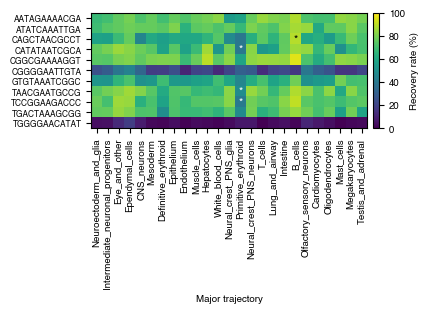

In [35]:
fig, ax = plt.subplots(figsize=(len(trajectory_recovery) * 0.15, 1.5))

trajectory_indices = [trajectory for trajectory in major_trajectory_color_plate if trajectory in trajectory_recovery.index]
im = ax.imshow(trajectory_recovery.loc[trajectory_indices, tape_columns].values.T, aspect='auto', cmap='viridis', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(trajectory_indices)))
ax.set_xticklabels(trajectory_indices, rotation=90,  ha='center', fontsize=7)
ax.set_yticks(np.arange(len(tape_columns)))
ax.set_yticklabels(tape_columns, fontsize=6)

ax.set_xlabel('Major trajectory')
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Recovery rate (%)')

sig_lookup = all_trajectory_results_df.set_index(['major_trajectory', 'tapebc'])[['sig_low', 'sig_high']]
for x_idx, trajectory in enumerate(trajectory_indices):
    for y_idx, tape_bc in enumerate(tape_columns):
        if (trajectory, tape_bc) not in sig_lookup.index: continue
        row = sig_lookup.loc[(trajectory, tape_bc)]
        if row['sig_low']: ax.text(x_idx, y_idx, '*', color='white', ha='center', va='center', fontsize=8, zorder=300)
        elif row['sig_high']: ax.text(x_idx, y_idx, '*', color='black', ha='center', va='center', fontsize=8, zorder=300)

#plt.savefig(f'{FIG_DIR}/tape_recovery_by_trajectory_heatmap.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [36]:
len(trajectory_recovery)

25

In [37]:
recovery_by_celltype = recovery.copy()
recovery_by_celltype['celltype'] = merged['celltype'].values
celltype_recovery = recovery_by_celltype.groupby('celltype')[tape_columns].mean() * 100
celltype_recovery = celltype_recovery.round(1)
celltype_recovery

,AATAGAAAACGA,ATATCAAATTGA,CAGCTAACGCCT,CATATAATCGCA,CGGCGAAAAGGT,CGGGGAATTGTA,GTGTAAATCGGC,TAACGAATGCCG,TCCGGAAGACCC,TGACTAAAGCGG,TGGGGAACATAT
celltype,,,,,,,,,,,
Adrenocortical cells,74.4,74.8,69.0,71.5,80.2,21.1,66.5,70.2,75.2,59.1,2.9
Amacrine/Horizontal precursor cells,76.4,80.6,83.3,84.7,77.8,45.8,66.7,83.3,73.6,84.7,5.6
Amniotic ectoderm,90.0,100.0,40.0,80.0,90.0,10.0,90.0,50.0,80.0,60.0,0.0
Anterior floor plate,73.2,71.3,62.4,69.3,72.7,23.4,48.3,77.8,65.3,75.3,4.7
Anterior roof plate,72.8,68.7,58.8,74.0,81.4,29.7,53.6,76.8,75.2,72.4,5.0
...,...,...,...,...,...,...,...,...,...,...,...
Thymic epithelial cells,86.1,80.6,58.3,88.9,80.6,25.0,75.0,80.6,91.7,91.7,0.0
Thyroid gland cells,87.5,65.6,84.4,75.0,90.6,21.9,46.9,65.6,81.2,75.0,6.2
Upper-layer neurons,75.0,50.0,50.0,100.0,75.0,50.0,75.0,75.0,50.0,75.0,0.0


In [38]:
celltype_counts = merged['celltype'].value_counts()
valid_celltypes = celltype_counts[celltype_counts >= 100].index

celltype_recovery_filtered = celltype_recovery.loc[celltype_recovery.index.isin(valid_celltypes)]

print(f'cell types before filtering: {len(celltype_recovery)}')
print(f'cell types after filtering (>= 100 cells): {len(celltype_recovery_filtered)}')

cell types before filtering: 138
cell types after filtering (>= 100 cells): 105


In [39]:
celltype2trajectory = sci.drop_duplicates('celltype').set_index('celltype')['major_trajectory'].to_dict()
celltype2trajectory

{'Sclerotome': 'Mesoderm',
 'Telencephalon': 'Neuroectoderm_and_glia',
 'Facial mesenchyme': 'Mesoderm',
 'Deep-layer neurons': 'Intermediate_neuronal_progenitors',
 'Hindbrain': 'Neuroectoderm_and_glia',
 'Myoblasts': 'Muscle_cells',
 'Fibroblasts': 'Mesoderm',
 'Glutamatergic neurons': 'CNS_neurons',
 'Spinal cord dorsal progenitors': 'CNS_neurons',
 'Hepatocytes': 'Hepatocytes',
 'Definitive early erythroblasts (CD36-)': 'Definitive_erythroid',
 'Cajal-Retzius cells': 'CNS_neurons',
 'Dermatome': 'Mesoderm',
 'Cerebellar Purkinje cells': 'CNS_neurons',
 'Branchial arch epithelium': 'Epithelium',
 'GABAergic cortical interneurons': 'CNS_neurons',
 'Lateral plate and intermediate mesoderm': 'Mesoderm',
 'Neural crest (PNS neurons)': 'Neural_crest_PNS_neurons',
 'Naive retinal progenitor cells': 'Eye_and_other',
 'Limb mesenchyme progenitors': 'Mesoderm',
 'Early chondrocytes': 'Mesoderm',
 'GABAergic neurons': 'CNS_neurons',
 'Border-associated macrophages': 'White_blood_cells',
 'Pre

In [40]:
celltype_recovery_filtered_mean = celltype_recovery_filtered[tape_columns].mean(axis=1)

ordered_celltypes = []
trajectory_group_ranges = []

current_idx = 0
for trajectory in major_trajectory_color_plate:
    celltypes_in_traj = [ct for ct in celltype_recovery_filtered.index if celltype2trajectory.get(ct) == trajectory]
    if len(celltypes_in_traj) == 0: continue
        
    celltypes_in_traj_sorted = celltype_recovery_filtered_mean.loc[celltypes_in_traj].sort_values(ascending=False).index.tolist()
    ordered_celltypes.extend(celltypes_in_traj_sorted)
    
    start_idx = current_idx
    end_idx = current_idx + len(celltypes_in_traj_sorted) - 1
    trajectory_group_ranges.append((trajectory, start_idx, end_idx))
    current_idx += len(celltypes_in_traj_sorted)
    
celltype_recovery_ordered = celltype_recovery_filtered.loc[ordered_celltypes]
celltype_recovery_ordered

,AATAGAAAACGA,ATATCAAATTGA,CAGCTAACGCCT,CATATAATCGCA,CGGCGAAAAGGT,CGGGGAATTGTA,GTGTAAATCGGC,TAACGAATGCCG,TCCGGAAGACCC,TGACTAAAGCGG,TGGGGAACATAT
celltype,,,,,,,,,,,
Retinal pigment cells,79.4,70.8,85.0,85.8,77.7,42.1,72.5,86.3,84.1,76.8,15.0
Diencephalon,73.8,78.7,70.0,85.9,81.1,41.3,58.9,82.0,83.6,79.9,12.6
Midbrain-hindbrain boundary,77.0,78.4,62.7,80.0,81.5,29.2,69.1,86.7,78.9,78.1,4.3
Eye field,71.9,72.2,61.8,81.9,79.3,34.1,58.3,74.8,81.0,78.3,8.1
Posterior roof plate,72.1,74.0,58.9,75.3,78.6,27.9,59.9,84.6,72.4,82.0,1.3
...,...,...,...,...,...,...,...,...,...,...,...
First heart field,70.0,60.6,61.3,65.9,61.8,30.3,53.4,71.0,71.0,70.7,6.9
Oligodendrocyte progenitor cells,69.5,76.0,52.5,77.5,71.5,26.0,55.5,84.0,74.0,77.0,4.0
Mast cells,83.6,75.3,67.2,50.5,83.2,15.6,79.1,60.5,68.3,57.2,0.1


In [41]:
def permutation_test_by_cell_shuffle_single_tape(recovery_vector, celltype_labels, target_celltype, n_permutations=100, seed=0):
    """
    recovery_vector: 1D boolean array (n_cells,), recovery status for ONE tape
    celltype_labels: 1D array of celltype label per cell (same order as recovery_vector)
    target_celltype: the celltype to test
    """
    rng = np.random.default_rng(seed)
    n_cells_total = len(recovery_vector)

    target_mask = (celltype_labels == target_celltype)
    n_target = target_mask.sum()

    observed_rate = recovery_vector[target_mask].mean() * 100

    null_rates = np.zeros(n_permutations)
    for i in range(n_permutations):
        random_idx = rng.choice(n_cells_total, size=n_target, replace=False)
        null_rates[i] = recovery_vector[random_idx].mean() * 100

    null_mean = null_rates.mean()
    p_value = np.mean(np.abs(null_rates - null_mean) >= np.abs(observed_rate - null_mean))

    return observed_rate, null_mean, p_value

In [42]:
celltype_labels = merged['celltype'].values

# run permutation test per (celltype, tape) combination
all_celltype_results = []
for tape_bc in good_tape_columns:
    recovery_vector = recovery[tape_bc].values  # boolean, shape (n_cells,)

    for celltype in valid_celltypes:
        observed_rate, null_mean, p_value = permutation_test_by_cell_shuffle_single_tape(
            recovery_vector, celltype_labels, celltype, n_permutations=100, seed=0
        )
        all_celltype_results.append({
            'tapebc': tape_bc,
            'celltype': celltype,
            'observed_rate': observed_rate,
            'null_mean_rate': null_mean,
            'diff_from_null': observed_rate - null_mean,
            'perm_p_value': p_value,
        })

all_celltype_results_df = pd.DataFrame(all_celltype_results)
all_celltype_results_df['perm_p_adjusted'] = multipletests(all_celltype_results_df['perm_p_value'], method='fdr_bh')[1]

# flag significant + lower-than-null per (celltype, tape)
FOLD_CHANGE_THRESHOLD = 1.5
all_celltype_results_df['fold_change'] = all_celltype_results_df['observed_rate'] / all_celltype_results_df['null_mean_rate']

all_celltype_results_df['sig_low'] = (all_celltype_results_df['perm_p_adjusted'] < 0.05) & (all_celltype_results_df['diff_from_null'] < 0) & (all_celltype_results_df['fold_change'] <= (1 / FOLD_CHANGE_THRESHOLD))
all_celltype_results_df['sig_high'] = (all_celltype_results_df['perm_p_adjusted'] < 0.05) & (all_celltype_results_df['diff_from_null'] > 0) & (all_celltype_results_df['fold_change'] >=  FOLD_CHANGE_THRESHOLD)
all_celltype_results_df

,tapebc,celltype,observed_rate,null_mean_rate,diff_from_null,perm_p_value,perm_p_adjusted,fold_change,sig_low,sig_high
0,AATAGAAAACGA,Glutamatergic neurons,73.718820,72.709411,1.009409,0.00,0.000000,1.013883,False,False
1,AATAGAAAACGA,Telencephalon,67.237346,72.704957,-5.467611,0.00,0.000000,0.924797,False,False
2,AATAGAAAACGA,Definitive early erythroblasts (CD36-),69.916766,72.700900,-2.784134,0.00,0.000000,0.961704,False,False
3,AATAGAAAACGA,Fibroblasts,77.292680,72.723263,4.569417,0.00,0.000000,1.062833,False,False
4,AATAGAAAACGA,GABAergic cortical interneurons,69.877530,72.724886,-2.847356,0.00,0.000000,0.960848,False,False
...,...,...,...,...,...,...,...,...,...,...
940,TGACTAAAGCGG,Satellite glial cells,79.844961,70.155039,9.689922,0.01,0.013979,1.138122,False,False
941,TGACTAAAGCGG,Pituitary gland cells,73.228346,70.929134,2.299213,0.68,0.714000,1.032416,False,False
942,TGACTAAAGCGG,Neural progenitor cells (Ror1+),78.861789,70.934959,7.926829,0.09,0.111908,1.111748,False,False
943,TGACTAAAGCGG,Placodal area,77.064220,70.623853,6.440367,0.13,0.156497,1.091193,False,False


In [43]:
pd.set_option('display.max_rows', 200)

In [44]:
sig_counts = all_celltype_results_df.groupby('celltype')[['sig_low', 'sig_high']].sum()
sig_counts.loc[:, 'high - low'] = sig_counts['sig_high'] - sig_counts['sig_low']

low_tapes_by_celltype = all_celltype_results_df[all_celltype_results_df['sig_low']].groupby('celltype')['tapebc'].apply(list)
high_tapes_by_celltype = all_celltype_results_df[all_celltype_results_df['sig_high']].groupby('celltype')['tapebc'].apply(list)

sig_counts['low_tapes'] = [low_tapes_by_celltype.get(celltype, []) for celltype in sig_counts.index]
sig_counts['high_tapes'] = [high_tapes_by_celltype.get(celltype, []) for celltype in sig_counts.index]

sig_counts = sig_counts.sort_values('high - low')
sig_counts

,sig_low,sig_high,high - low,low_tapes,high_tapes
celltype,,,,,
Definitive erythroblasts (CD36+),6,0,-6,"[CAGCTAACGCCT, CATATAATCGCA, CGGCGAAAAGGT, TAA...",[]
Primitive erythroid cells,3,0,-3,"[CATATAATCGCA, TAACGAATGCCG, TCCGGAAGACCC]",[]
Kupffer cells,2,0,-2,"[CATATAATCGCA, TGACTAAAGCGG]",[]
Monocytic myeloid-derived suppressor cells,2,0,-2,"[TAACGAATGCCG, TCCGGAAGACCC]",[]
Neural crest (PNS glia),1,0,-1,[CAGCTAACGCCT],[]
Satellite glial cells,1,0,-1,[CAGCTAACGCCT],[]
Microglia,1,0,-1,[CATATAATCGCA],[]
Myelinating Schwann cells,1,0,-1,[AATAGAAAACGA],[]
Border-associated macrophages,1,0,-1,[CATATAATCGCA],[]


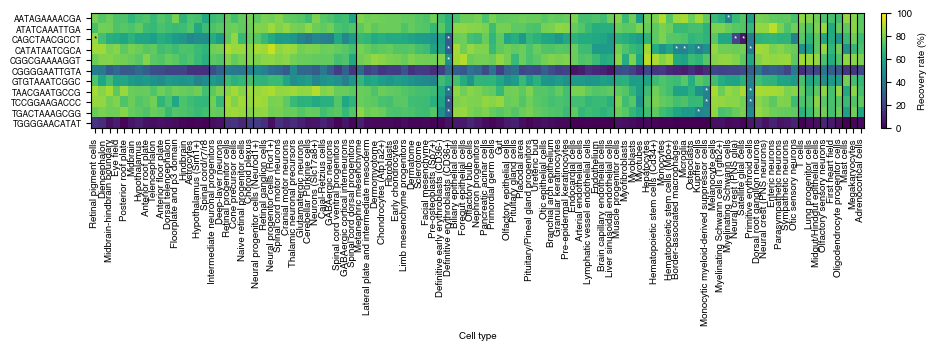

In [45]:
fig, ax = plt.subplots(figsize=(len(celltype_recovery_ordered) * 0.1, 1.5))

im = ax.imshow(celltype_recovery_ordered[tape_columns].values.T, aspect='auto', cmap='viridis', vmin=0, vmax=100)

ax.set_xticks(np.arange(len(celltype_recovery_ordered)))
ax.set_xticklabels(celltype_recovery_ordered.index, rotation=90, ha='center', fontsize=7)
ax.set_yticks(np.arange(len(tape_columns)))
ax.set_yticklabels(tape_columns, fontsize=6)
ax.set_xlabel('Cell type')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Recovery rate (%)')

for trajectory, start_idx, end_idx in trajectory_group_ranges[:-1]:
    ax.axvline(x=end_idx + 0.5, color='black', linestyle='-', linewidth=0.8, zorder=200)

sig_lookup = all_celltype_results_df.set_index(['celltype', 'tapebc'])[['sig_low', 'sig_high']]
for x_idx, celltype in enumerate(celltype_recovery_ordered.index):
    for y_idx, tape_bc in enumerate(tape_columns):
        if (celltype, tape_bc) not in sig_lookup.index: continue
        row = sig_lookup.loc[(celltype, tape_bc)]
        if row['sig_low']: ax.text(x_idx, y_idx, '*', color='white', ha='center', va='center', fontsize=6, zorder=300)
        elif row['sig_high']: ax.text(x_idx, y_idx, '*', color='black', ha='center', va='center', fontsize=6, zorder=300)

#plt.savefig(f'{FIG_DIR}/tape_recovery_by_celltype_heatmap.ordered_by_trajectories.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [46]:
import scanpy as sc

In [47]:
sci_qc = pd.read_table(f'{DATA_DIR_SCI}/e3v8.sc_qc.tsv.gz')
sci_qc.columns = ['cell_id'] + sci_qc.columns[1:].tolist()
sci_qc

,cell_id,n_loci,n_doublet_loci,mean_dominance,total_molecules
0,exp1_PA-02A.LIG-P3-A01_RT-P3-B07,2,0,1.0,13
1,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,7,0,1.0,88
2,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,7,0,1.0,72
3,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,9,0,1.0,112
4,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,6,0,1.0,95
...,...,...,...,...,...
1559414,exp2_PY-12H.LIG-P6-H11_RT-P6-H12,3,0,1.0,21
1559415,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,8,0,1.0,40
1559416,exp2_PY-12H.LIG-P6-H12_RT-P6-D02,6,0,1.0,43
1559417,exp2_PY-12H.LIG-P6-H12_RT-P7-C03,7,0,1.0,36


In [48]:
adata = sc.read_h5ad('/net/shendure/vol10/www/content/members/cxqiu/private/nobackup/tapemouse/adata_embryo3.h5ad')
adata

AnnData object with n_obs × n_vars = 1584848 × 78258
    var: 'chr', 'start', 'end', 'strand', 'gene_type', 'gene_short_name'

In [49]:
cell_umi_counts = np.ravel(adata.X.sum(axis=1))
umi_series = pd.Series(cell_umi_counts, index=adata.obs_names, name='transcriptome_umi')
umi_series

exp1_PA-02A.LIG-P8-F09_RT-P8-H07    1101.0
exp1_PA-02A.LIG-P8-D11_RT-P7-C07     373.0
exp1_PA-02A.LIG-P6-D07_RT-P7-D12     906.0
exp1_PA-02A.LIG-P8-A09_RT-P8-C12    1354.0
exp1_PA-02A.LIG-P7-H07_RT-P8-A07     756.0
                                     ...  
exp2_PY-12H.LIG-P5-A08_RT-P7-F07    1188.0
exp2_PY-12H.LIG-P5-B07_RT-P3-A02     467.0
exp2_PY-12H.LIG-P5-B07_RT-P3-A06    1488.0
exp2_PY-12H.LIG-P6-G07_RT-P7-D02     415.0
exp2_PY-12H.LIG-P4-G09_RT-P3-G10     848.0
Name: transcriptome_umi, Length: 1584848, dtype: float32

In [50]:
sci_qc['transcriptome_umi'] = sci_qc['cell_id'].map(umi_series)
sci_qc

,cell_id,n_loci,n_doublet_loci,mean_dominance,total_molecules,transcriptome_umi
0,exp1_PA-02A.LIG-P3-A01_RT-P3-B07,2,0,1.0,13,1796.0
1,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,7,0,1.0,88,624.0
2,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,7,0,1.0,72,954.0
3,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,9,0,1.0,112,1268.0
4,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,6,0,1.0,95,1636.0
...,...,...,...,...,...,...
1559414,exp2_PY-12H.LIG-P6-H11_RT-P6-H12,3,0,1.0,21,336.0
1559415,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,8,0,1.0,40,747.0
1559416,exp2_PY-12H.LIG-P6-H12_RT-P6-D02,6,0,1.0,43,673.0
1559417,exp2_PY-12H.LIG-P6-H12_RT-P7-C03,7,0,1.0,36,659.0


In [51]:
# merged: cells that passed qc
sci_qc = sci_qc.merge(merged[['cell_id', 'major_trajectory', 'celltype']], on='cell_id', how='inner')
sci_qc

,cell_id,n_loci,n_doublet_loci,mean_dominance,total_molecules,transcriptome_umi,major_trajectory,celltype
0,exp1_PA-02A.LIG-P3-A02_RT-P5-H08,7,0,1.0,88,624.0,Muscle_cells,Myoblasts
1,exp1_PA-02A.LIG-P3-A04_RT-P6-C08,7,0,1.0,72,954.0,CNS_neurons,GABAergic cortical interneurons
2,exp1_PA-02A.LIG-P3-A05_RT-P5-D12,9,0,1.0,112,1268.0,CNS_neurons,Glutamatergic neurons
3,exp1_PA-02A.LIG-P3-A05_RT-P6-B11,6,0,1.0,95,1636.0,Neuroectoderm_and_glia,Telencephalon
4,exp1_PA-02A.LIG-P3-A07_RT-P6-H12,7,0,1.0,45,1324.0,CNS_neurons,Glutamatergic neurons
...,...,...,...,...,...,...,...,...
1296794,exp2_PY-12H.LIG-P6-H11_RT-P6-H04,5,0,1.0,23,847.0,CNS_neurons,Glutamatergic neurons
1296795,exp2_PY-12H.LIG-P6-H12_RT-P5-B05,8,0,1.0,40,747.0,Mesoderm,Lateral plate and intermediate mesoderm
1296796,exp2_PY-12H.LIG-P6-H12_RT-P6-D02,6,0,1.0,43,673.0,Mesoderm,Facial mesenchyme
1296797,exp2_PY-12H.LIG-P6-H12_RT-P7-C03,7,0,1.0,36,659.0,Epithelium,Otic epithelial cells


In [52]:
celltype_counts = sci_qc['celltype'].value_counts()
valid_celltypes = celltype_counts[celltype_counts >= 100].index
sci_qc_filtered = sci_qc[sci_qc['celltype'].isin(valid_celltypes)]

celltype_summary = (sci_qc_filtered.groupby('celltype').agg({'transcriptome_umi': 'mean',
                                                             'total_molecules': 'mean',
                                                             'major_trajectory': 'first'}).reset_index()).sort_values('total_molecules', ascending=False)
celltype_summary

,celltype,transcriptome_umi,total_molecules,major_trajectory
21,Dorsal root ganglion neurons,2691.789307,160.139303,Neural_crest_PNS_neurons
12,Choroid plexus,1245.185669,149.924191,Ependymal_cells
52,Megakaryocytes,1314.180176,140.145785,Megakaryocytes
97,Spinal cord motor neurons,2604.772461,128.826790,CNS_neurons
5,Biliary epithelial cells,1406.391846,121.060811,Epithelium
91,Retinal ganglion cells,1281.592651,118.722022,CNS_neurons
26,Enteric neurons,2227.075684,117.846341,Neural_crest_PNS_neurons
81,Pancreatic acinar cells,1277.053101,117.600000,Epithelium
32,Foregut epithelial cells,1397.478027,115.118421,Epithelium
71,Neural progenitor cells (Neurod1+),1162.535767,112.376631,CNS_neurons


In [53]:
celltype_summary['sig_low'] = celltype_summary['celltype'].map(sig_counts['sig_low']).fillna(0).astype(int)
celltype_summary.sort_values('sig_low', ascending=False)

,celltype,transcriptome_umi,total_molecules,major_trajectory,sig_low
17,Definitive erythroblasts (CD36+),640.764709,40.202941,Definitive_erythroid,6
89,Primitive erythroid cells,501.769226,50.708333,Primitive_erythroid,3
60,Monocytic myeloid-derived suppressor cells,997.492432,50.977273,White_blood_cells,2
45,Kupffer cells,1316.556030,67.158015,White_blood_cells,2
94,Satellite glial cells,1324.069824,77.953488,Neural_crest_PNS_glia,1
6,Border-associated macrophages,876.835632,67.921441,White_blood_cells,1
55,Microglia,1049.537964,70.509025,White_blood_cells,1
69,Neural crest (PNS glia),896.718140,71.460208,Neural_crest_PNS_glia,1
62,Myelinating Schwann cells,1339.898193,81.872940,Neural_crest_PNS_glia,1
2,Anterior roof plate,1033.383911,69.294118,Neuroectoderm_and_glia,0


In [54]:
from scipy.stats import spearmanr

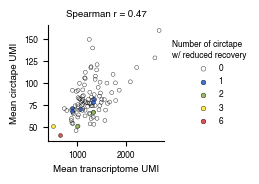

In [55]:
sig_low_colors = {0: 'None', 1: '#2F60C9', 2: '#91B155', 3: '#FCE83C', 6: '#DA3C3D'}

fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.5))

for val in celltype_summary['sig_low'].sort_values().unique():
    grp = celltype_summary.loc[celltype_summary['sig_low'] == val]
    if len(grp) == 0: continue
    ax.scatter(grp['transcriptome_umi'], grp['total_molecules'], c=sig_low_colors[val], s=8, alpha=0.9, edgecolor='black', linewidth=0.3, label=str(val), zorder=10 + val)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('Mean transcriptome UMI', fontsize=7)
ax.set_ylabel('Mean circtape UMI', fontsize=7)
ax.tick_params(axis='both', labelsize=6)

corr, pval = spearmanr(celltype_summary['transcriptome_umi'], celltype_summary['total_molecules'])
ax.set_title(f'Spearman r = {corr:.2f}', fontsize=7)

ax.legend(title='Number of circtape\nw/ reduced recovery', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=6, title_fontsize=6, markerscale=1.2)

#plt.savefig(f'{FIG_DIR}/mean_transcriptome_umi_vs_tape_umi.by_sig_low_discrete.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [56]:
pval

4.856585457621745e-07